In [1]:
import torch
import torch.nn as nn

from mslandcover.models import DeepLabV3Plus, ResNetBackbone, UNet, ResNetBackboneUNet, AttentionUNet, BYOLWrapper
from mslandcover.utils import load_pth
import rasterio as rio
from glob import iglob, glob
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
test_images = glob('/scratch/dhester/mslc_data_v2/pretrain_val/*.tif')
# select first 32 test images
# randomly sample 2048 test images
test_images = np.random.choice(test_images, 16384, replace=False)
# test_images = [next(test_images) for _ in range(8192)]


x_batch = torch.stack([torch.from_numpy(rio.open(img).read([4, 1, 2])).float() / 255.0 for img in test_images])

mean = torch.load('./weights/pretrain_mean.pth')
std = torch.load('./weights/pretrain_std.pth')

x_batch = (x_batch - mean[None, :, None, None]) / std[None, :, None, None]

In [ ]:


backbone = ResNetBackboneUNet(in_channels=3, pretrained=False)

x = torch.randn(2, 3, 256, 256)
backbone.eval()
with torch.no_grad():
    features = backbone(x)

In [4]:
for feature in features:
    print(feature.shape)

torch.Size([2, 64, 128, 128])
torch.Size([2, 256, 64, 64])
torch.Size([2, 512, 32, 32])
torch.Size([2, 1024, 16, 16])
torch.Size([2, 2048, 8, 8])


In [ ]:



# weights_1 = torch.load('weights/resnet101_202506/byol_bands3_size256_randinitfalse/resnet101/byol.pth', map_location='cpu')
# weights_2 = torch.load('weights/resnet101_20250616/byol_bands3_size256_randinitfalse/resnet101/byol_last.pth', map_location='cpu')
byol_weights = torch.load('./weights/resnet101_20250720/byol_bands3_size256_randinitfalse/resnet101/byol_last.pth', map_location='cpu')
# byol_collapsed_weights = torch.load('weights/resnet101_20250616/byol_bands3_size256_randinitfalse/resnet101/byol_last.pth', map_location='cpu')
byol_collapsed_weights = torch.load('./weights/resnet101_20250720/byol_bands3_size256_randinittrue/resnet101_randinit/byol_last.pth', map_location='cpu')
finetuned_weights = torch.load('./weights/finetuned_unet/best_model.pth')

/tmp/ipykernel_3444007/165198263.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  byol_weights = torch.load('./weights/resnet101_20250720/byol_bands3_size256_randinitfals

In [ ]:
from tqdm import trange
batch_size = 64

model = models.resnet101(weights=None)
model.fc = nn.Identity()  # Remove the final classification layer
model.eval()
model = model.to('cuda')

h_random = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part.to('cuda')).cpu().detach().numpy()
    h_random.append(h_part)
h_random = np.concatenate(h_random, axis=0)

model = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2)
model.fc = nn.Identity()  # Remove the final classification layer
model.eval()
model = model.to('cuda')

h_inet = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part.to('cuda')).cpu().detach().numpy()
    h_inet.append(h_part)
h_inet = np.concatenate(h_inet, axis=0)

byol_collapsed_weights_adj = {}
for key in list(byol_collapsed_weights.keys()):
    if key.startswith('online_encoder.0.'):
        new_key = key.replace('online_encoder.0.', '')
        byol_collapsed_weights_adj[new_key] = byol_collapsed_weights[key]
model.load_state_dict(byol_collapsed_weights_adj, strict=True)

h_byol_collapsed = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part.to('cuda')).cpu().detach().numpy()
    h_byol_collapsed.append(h_part)
h_byol_collapsed = np.concatenate(h_byol_collapsed, axis=0)

byol_weights_adj = {}
for key in list(byol_weights.keys()):
    if key.startswith('online_encoder.0.'):
        new_key = key.replace('online_encoder.0.', '')
        byol_weights_adj[new_key] = byol_weights[key]
model.load_state_dict(byol_weights_adj, strict=True)

h_byol = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part.to('cuda')).cpu().detach().numpy()
    h_byol.append(h_part)
# h_byol = torch.cat(h_byol, dim=0)
h_byol = np.concatenate(h_byol, axis=0)

100%|██████████| 256/256 [00:12<00:00, 20.20it/s]


In [17]:

finetuned_weights_adj = {}
for key in list(finetuned_weights.keys()):
    if key.startswith('backbone.'):
        new_key = key.replace('backbone.', '')
        
        if new_key.startswith('initial.0'):
            new_key = new_key.replace('initial.0', 'conv1')
        elif new_key.startswith('initial.1'):
            new_key = new_key.replace('initial.1', 'bn1')
        
        finetuned_weights_adj[new_key] = finetuned_weights[key]
model.load_state_dict(finetuned_weights_adj, strict=True)

h_finetuned = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part.to('cuda')).cpu().detach().numpy()
    h_finetuned.append(h_part)
# h_finetuned = torch.cat(h_finetuned, dim=0)
h_finetuned = np.concatenate(h_finetuned, axis=0)

  0%|          | 0/370 [00:00<?, ?it/s]

100%|██████████| 370/370 [01:08<00:00,  5.39it/s]


In [ ]:
import os
os.makedirs('./val_embeddings', exist_ok=True)

np.save('./val_embeddings/h_random.npy', h_random)
np.save('./val_embeddings/h_inet.npy', h_inet)
np.save('./val_embeddings/h_byol_collapsed.npy', h_byol_collapsed)
np.save('./val_embeddings/h_byol.npy', h_byol)
np.save('./val_embeddings/h_finetuned.npy', h_finetuned)

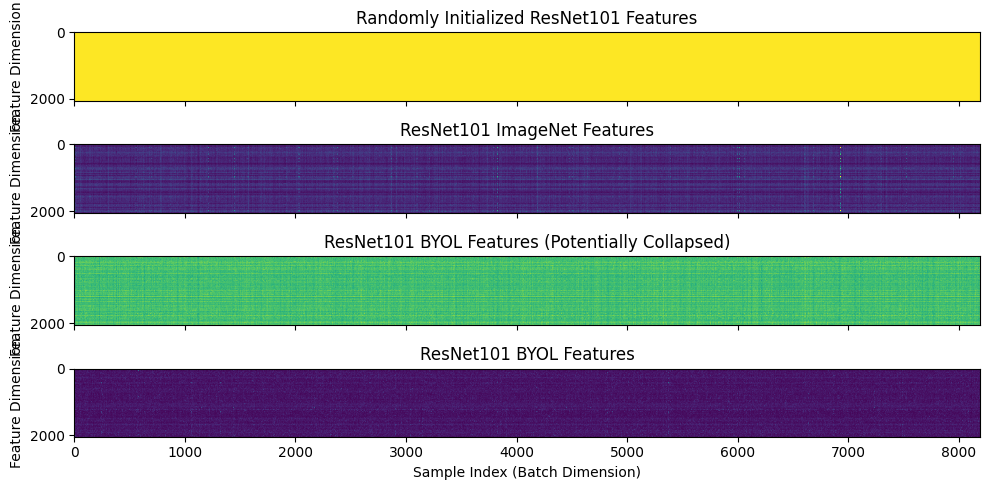

In [21]:
fig, ax = plt.subplots(4, 1, figsize=(10, 5), sharex=True)

vmax = 1
ax[0].imshow(h_random.T, vmin=0, vmax=vmax)
ax[0].set_title('Randomly Initialized ResNet101 Features')
ax[0].set_ylabel('Feature Dimension')

ax[1].imshow(h_inet.T, vmin=0, vmax=vmax)
ax[1].set_title('ResNet101 ImageNet Features')
ax[1].set_ylabel('Feature Dimension')

ax[2].imshow(h_byol_collapsed.T, vmin=0, vmax=vmax)
ax[2].set_title('ResNet101 BYOL Features (Potentially Collapsed)')
ax[2].set_ylabel('Feature Dimension')

ax[3].imshow(h_byol.T, vmin=0, vmax=vmax)
ax[3].set_title('ResNet101 BYOL Features')
ax[3].set_ylabel('Feature Dimension')

ax[3].set_xlabel('Sample Index (Batch Dimension)')

for a in ax:
    a.set_aspect('auto')

fig.tight_layout()
plt.show()

In [19]:
# shape (N, M) # where N is the number of samples (batch dimension) and M is the feature dimension

print(f'H_random std: {h_random.std(axis=0).mean()}')
print(f'H_inet std: {h_inet.std(axis=0).mean()}')
print(f'H_byol_collapsed std: {h_byol_collapsed.std(axis=0).mean()}')
print(f'H_byol std: {h_byol.std(axis=0).mean()}')

H_random std: 3751.147705078125
H_inet std: 0.201298326253891
H_byol_collapsed std: 0.31883078813552856
H_byol std: 0.26837098598480225


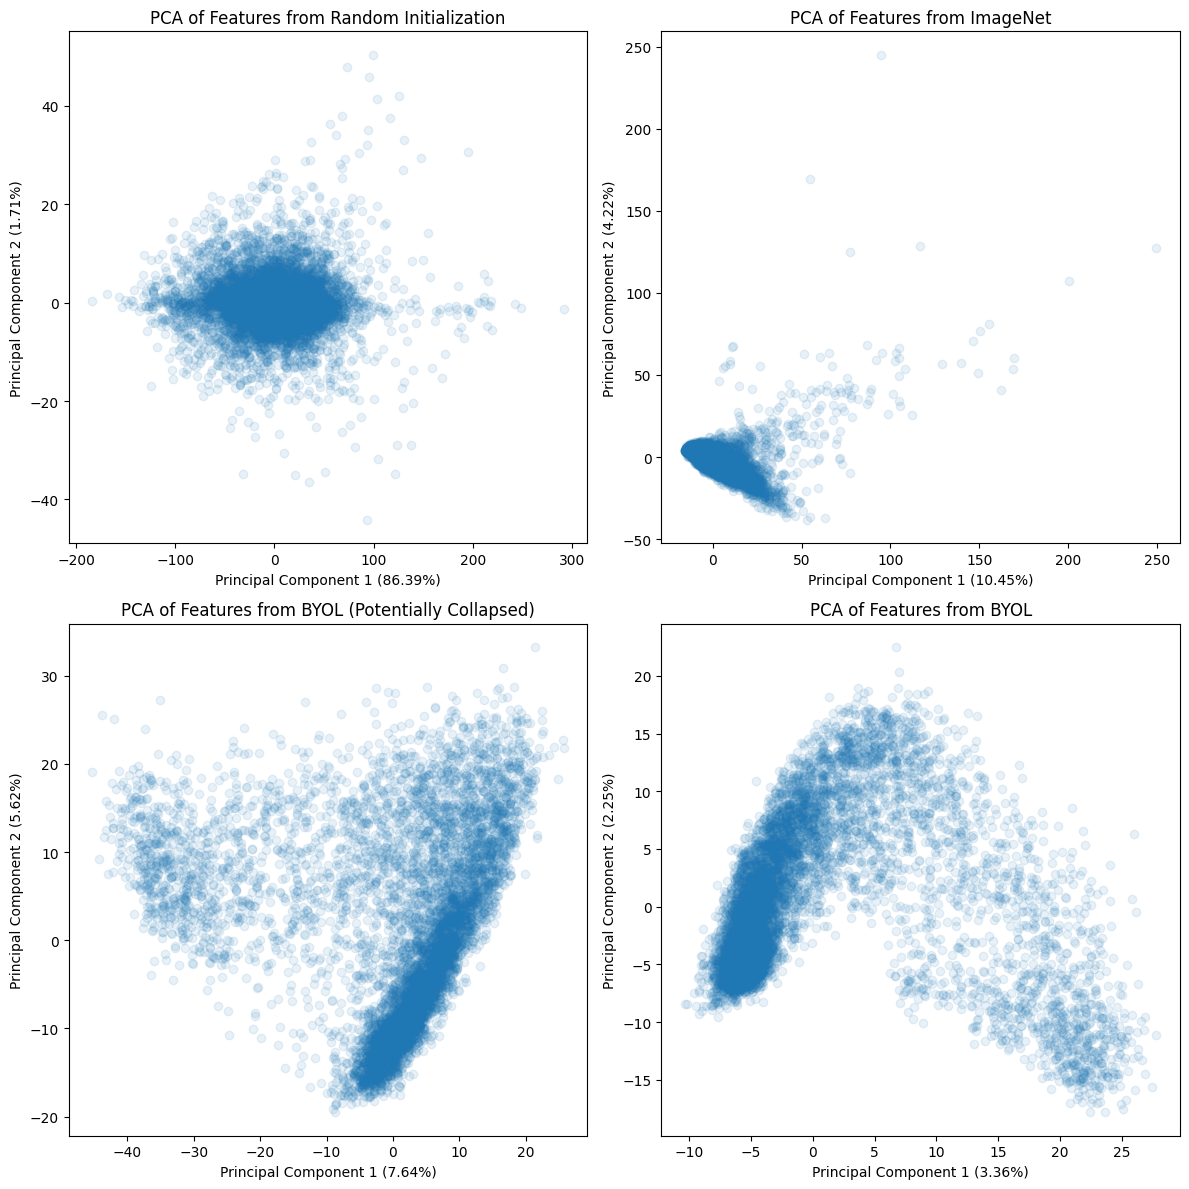

In [22]:
# view principal components of features
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

fig, ax = plt.subplots(2, 2, figsize=(12, 12))
ax = ax.ravel()

# feature_models = ['ImageNet', 'BYOL (weights_1)', 'BYOL (weights_2)', 'BYOL (weights_3)']
# feature_models = ['Random Initialization', 'ImageNet', 'BYOL', 'Finetuned']
feature_models = ['Random Initialization', 'ImageNet', 'BYOL (Potentially Collapsed)', 'BYOL']

# for i, embeddings in enumerate([h_random, h_inet, h_byol, h_finetuned]):
for i, embeddings in enumerate([h_random, h_inet, h_byol_collapsed, h_byol]):
    # Flatten the embeddings
    # flattened_embeddings = embeddings.view(embeddings.size(0), -1).detach().numpy()
    
    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=2)
    )
    pca_embeddings = pipe.fit_transform(embeddings)
    
    # Plot the PCA results
    ax[i].scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], alpha=0.1)
    ax[i].set_title(f'PCA of Features from {feature_models[i]}')
    ax[i].set_xlabel(f'Principal Component 1 ({pipe['pca'].explained_variance_ratio_[0]:.2%})')
    ax[i].set_ylabel(f'Principal Component 2 ({pipe['pca'].explained_variance_ratio_[1]:.2%})')

fig.tight_layout()
plt.show()

In [23]:
# print(f'H_inet std: {h_inet.std(axis=0).mean()}')
# print(f'H_1 std: {h_1.std(axis=1).mean()}')
# print(f'H_2 std: {h_2.std(axis=1).mean()}')
# print(f'H_3 std: {h_3.std(axis=1).mean()}')

print(f'h_random std: {h_random.std(axis=0).mean()}')
print(f'H_inet std: {h_inet.std(axis=0).mean()}')
print(f'H_byol_collapsed std: {h_byol_collapsed.std(axis=0).mean()}')
print(f'H_byol std: {h_byol.std(axis=0).mean()}')
# print(f'H_finetuned std: {h_finetuned.std(axis=0

h_random std: 3751.147705078125
H_inet std: 0.201298326253891
H_byol_collapsed std: 0.31883078813552856
H_byol std: 0.26837098598480225


In [168]:
print(h_inet.std(axis=0).shape) # standard deviation of features across samples
# print(h_inet.std(axis=1).shape) # standard deviation of samples across features

(2048,)


UMAP( verbose=True)
Sat Jul 26 21:52:22 2025 Construct fuzzy simplicial set
Sat Jul 26 21:52:22 2025 Finding Nearest Neighbors
Sat Jul 26 21:52:22 2025 Building RP forest with 10 trees
Sat Jul 26 21:52:27 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Sat Jul 26 21:52:37 2025 Finished Nearest Neighbor Search
Sat Jul 26 21:52:38 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sat Jul 26 21:53:17 2025 Finished embedding
UMAP( verbose=True)
Sat Jul 26 21:53:17 2025 Construct fuzzy simplicial set
Sat Jul 26 21:53:18 2025 Finding Nearest Neighbors
Sat Jul 26 21:53:18 2025 Building RP forest with 10 trees
Sat Jul 26 21:53:18 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Sat Jul 26 21:53:20 2025 Finished Nearest Neighbor Search
Sat Jul 26 21:53:20 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sat Jul 26 21:53:40 2025 Finished embedding
UMAP( verbose=True)
Sat Jul 26 21:53:40 2025 Construct fuzzy simplicial set
Sat Jul 26 21:53:40 2025 Finding Nearest Neighbors
Sat Jul 26 21:53:40 2025 Building RP forest with 10 trees
Sat Jul 26 21:53:40 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Sat Jul 26 21:53:42 2025 Finished Nearest Neighbor Search
Sat Jul 26 21:53:42 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sat Jul 26 21:54:04 2025 Finished embedding
UMAP( verbose=True)
Sat Jul 26 21:54:04 2025 Construct fuzzy simplicial set
Sat Jul 26 21:54:04 2025 Finding Nearest Neighbors
Sat Jul 26 21:54:04 2025 Building RP forest with 10 trees
Sat Jul 26 21:54:04 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Sat Jul 26 21:54:07 2025 Finished Nearest Neighbor Search
Sat Jul 26 21:54:07 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sat Jul 26 21:54:30 2025 Finished embedding


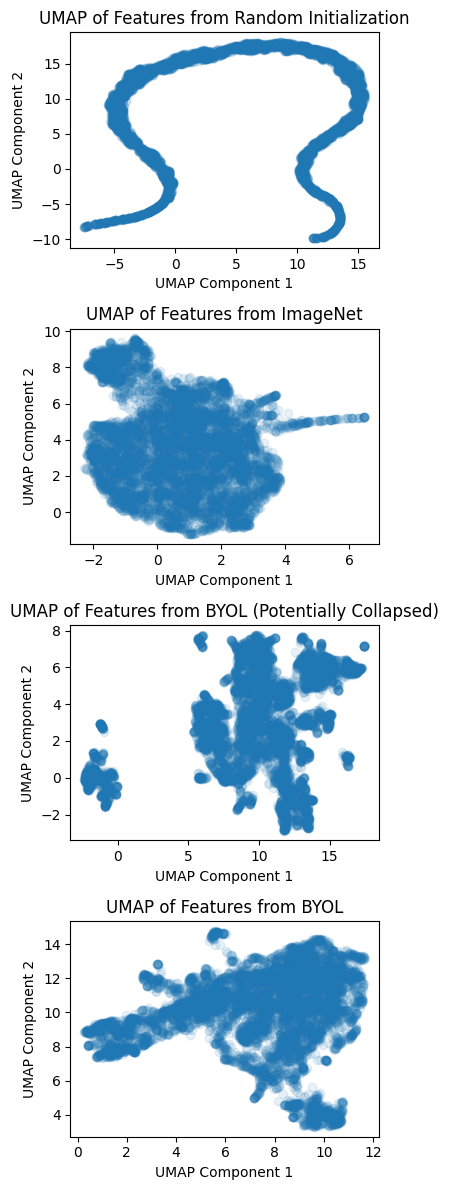

In [11]:
# apply umap 
from umap import UMAP



fig, ax = plt.subplots(4, 1, figsize=(4, 12))
# for i, umap_embeddings in enumerate([h_inet, h_1, h_2, h_3]):
for i, h in enumerate([h_random, h_inet, h_byol_collapsed, h_byol]):
    model = UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric='euclidean',
        # random_state=42,
        verbose=True,
        n_jobs=-1
    )
    
    umap_embeddings = model.fit_transform(h)
    
    ax[i].scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], alpha=0.1)
    ax[i].set_title(f'UMAP of Features from {feature_models[i]}')
    ax[i].set_xlabel('UMAP Component 1')
    ax[i].set_ylabel('UMAP Component 2')

fig.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import normalize

def analyze_embeddings(X):
    # X = X - X.mean(axis=0)
    X = normalize(X, axis=0)  # Normalize features to unit norm
    cov = np.cov(X, rowvar=False)  # shape (d, d)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.clip(eigvals, a_min=1e-10, a_max=None)  # avoid divide-by-zero

    pr = (np.sum(eigvals) ** 2) / np.sum(eigvals ** 2)
    isotropy = eigvals.min() / eigvals.max()
    condition_number = eigvals.max() / eigvals.min()

    return {
        "eigvals": np.sort(eigvals)[::-1],
        "participation_ratio": pr,
        "isotropy_index": isotropy,
        "condition_number": condition_number
    }
    
# for i, embeddings in enumerate([h_inet, h_1, h_2, h_3]):
for i, embeddings in enumerate([h_random, h_inet, h_byol_collapsed, h_byol]):
    analysis = analyze_embeddings(embeddings)
    print(f"Analysis for {feature_models[i]}:")
    print(f"  Participation Ratio: {analysis['participation_ratio']:.4f}")
    print(f"  Isotropy Index: {analysis['isotropy_index']:.4f}")
    print(f"  Condition Number: {analysis['condition_number']:.4f}")
    print(f"  Eigenvalues: {analysis['eigvals'][:10]}...")  # Show first 10 eigenvalues
    
    # how many PCs make up 95% variance
    analysis['eigvals'] = analysis['eigvals']  # Sort eigenvalues in descending order
    cumulative_variance = np.cumsum(analysis['eigvals']) / np.sum(analysis['eigvals'])
    num_pcs_95 = np.argmax(cumulative_variance >= 0.95) + 1  # +1 because np.argmax returns index
    print(f"  Number of PCs for 95% variance: {num_pcs_95}")
    
    print()

Analysis for Random Initialization:
  Participation Ratio: 4.8823
  Isotropy Index: 0.0000
  Condition Number: 82762245.2690
  Eigenvalues: [0.00827622 0.00057863 0.00047916 0.00046097 0.00037299 0.00032334
 0.00027581 0.00025439 0.00021212 0.00020792]...
  Number of PCs for 95% variance: 77

Analysis for ImageNet:
  Participation Ratio: 54.0414
  Isotropy Index: 0.0000
  Condition Number: 1381596.7304
  Eigenvalues: [0.02235232 0.00909702 0.00617576 0.00521332 0.00407297 0.00321142
 0.00276448 0.00251619 0.00242142 0.00235002]...
  Number of PCs for 95% variance: 1153

Analysis for BYOL (Potentially Collapsed):
  Participation Ratio: 36.5345
  Isotropy Index: 0.0000
  Condition Number: 161666.1036
  Eigenvalues: [0.00407291 0.0031581  0.00197529 0.00175272 0.00166997 0.00147071
 0.00142062 0.00130653 0.00122175 0.00118487]...
  Number of PCs for 95% variance: 218

Analysis for BYOL:
  Participation Ratio: 216.0606
  Isotropy Index: 0.0000
  Condition Number: 26439.3895
  Eigenvalues: 

In [ ]:
# how many PCs make up 95% of variation?


array([1.00000000e-10, 1.00000000e-10, 1.00000000e-10, ...,
       3.26175272e-02, 3.54002405e-02, 4.58390025e-02])

Plotting cosine similarity histogram for Random Initialization...
Mean Cosine Similarity: 0.9998
Std Dev: 0.0003
Plotting cosine similarity histogram for ImageNet...
Mean Cosine Similarity: 0.4634
Std Dev: 0.1617
Plotting cosine similarity histogram for BYOL (Potentially Collapsed)...
Mean Cosine Similarity: 0.8153
Std Dev: 0.0661
Plotting cosine similarity histogram for BYOL...
Mean Cosine Similarity: 0.0722
Std Dev: 0.0985


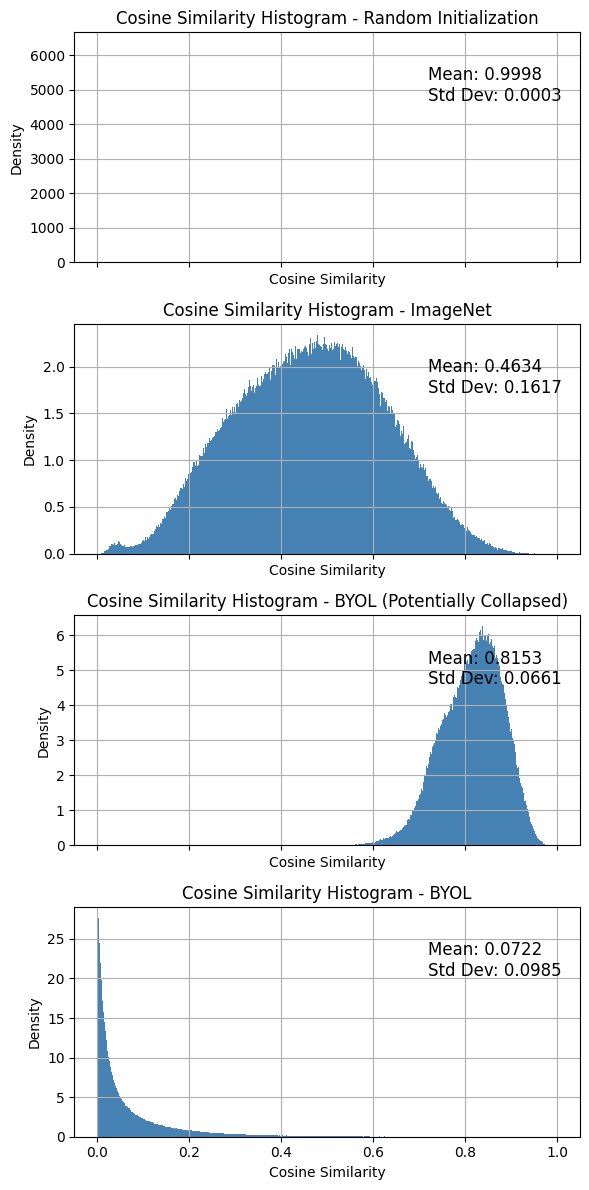

In [25]:
from sklearn.preprocessing import normalize

def plot_cosine_histogram(X, num_samples=100000, bins=100, ax=None):
    """
    X: (N, d) numpy array of embeddings
    num_samples: number of random pairs to sample
    bins: histogram resolution
    """

    # Normalize embeddings to unit vectors
    X_norm = normalize(X, axis=1)

    N = X.shape[0]
    sim_scores = []

    # Sample random pairs
    for _ in range(num_samples):
        i, j = np.random.randint(0, N, size=2)
        sim = np.dot(X_norm[i], X_norm[j])
        sim_scores.append(sim)

    sim_scores = np.array(sim_scores)

    # Plot
    if ax is None:
        ax = plt.subplots(figsize=(8, 6))
        
    ax.hist(sim_scores, bins=bins, density=True, color='steelblue')
    # ax.suptitle("Histogram of Cosine Similarities Between Embeddings")
    # ax.subtitle("Cosine Similarity Histogram")
    # ax.set_title("Cosine Similarity Histogram")
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Density")
    ax.grid(True)
    
    ax.text(0.7, 0.7, f"Mean: {sim_scores.mean():.4f}\nStd Dev: {sim_scores.std():.4f}",
            transform=ax.transAxes, fontsize=12)
    fig.tight_layout()
    fig.show()

    # Summary statistics
    print(f"Mean Cosine Similarity: {sim_scores.mean():.4f}")
    print(f"Std Dev: {sim_scores.std():.4f}")


fig, ax = plt.subplots(4, 1, figsize=(6, 12), sharex=True)
# for i, embeddings in enumerate([h_inet, h_1, h_2, h_3]):
for i, embeddings in enumerate([h_random, h_inet, h_byol_collapsed, h_byol]):
    print(f"Plotting cosine similarity histogram for {feature_models[i]}...")
    plot_cosine_histogram(embeddings, num_samples=1000000, bins=1000, ax=ax[i])
    ax[i].set_title(f"Cosine Similarity Histogram - {feature_models[i]}")
    # print()
    # print(f"Mean Cosine Similarity: {embeddings.detach().numpy().mean():.4f}")
    # print(f"Std Dev: {embeddings.detach().numpy().std():.4f}")
        # print(f"Max Cosne Similarity: {embeddings.detach().numpy().max():.4f}")
    # print(f"Min Cosine Similarity: {embeddings.detach().numpy().min():.4f}")
    # print(f"Shape: {embeddings.shape}")
    # print(f"Mean: {embeddings.mean():.4f}")
    # print(f"Std: {embeddings.std():.4f}")

In [13]:
# p(h < 0.2)

print(f'P[H_inet < 0.1] = {np.mean(h_inet < 0.1):.4f}')
print(f'P[H_random < 0.1] = {np.mean(h_random < 0.1):.4f}')
print(f'P[H_byol_collapsed < 0.1] = {np.mean(h_byol_collapsed < 0.1):.4f}')
print(f'P[H_byol < 0.1] = {np.mean(h_byol < 0.1):.4f}')

P[H_inet < 0.1] = 0.7749
P[H_random < 0.1] = 0.0471
P[H_byol_collapsed < 0.1] = 0.9158
P[H_byol < 0.1] = 0.8172


In [38]:
from scipy.spatial.distance import pdist

def plot_distance_histogram(X, metric='euclidean', num_samples=100000, bins=100, ax=None):
    
    X_norm = normalize(X, axis=1)  # Normalize embeddings to unit vectors
    """
    X: (N, d) numpy array of embeddings
    metric: distance metric to use
    num_samples: number of random pairs to sample
    bins: histogram resolution
    """
    
    # Compute pairwise distances
    distances = pdist(X_norm, metric=metric)
    
    # Sample random distances if needed
    if len(distances) > num_samples:
        distances = np.random.choice(distances, size=num_samples, replace=False)
    
    # # Plot histogram
    # plt.figure(figsize=(8, 6))
    # plt.hist(distances, bins=bins, density=True, color='steelblue', edgecolor='black')
    # plt.title(f"Histogram of {metric.capitalize()} Distances Between Embeddings")
    # plt.xlabel(f"{metric.capitalize()} Distance")
    # plt.ylabel("Density")
    # plt.grid(True)
    
    # plt.text(0.8, 0.8, f"Mean: {distances.mean():.4f}\nStd Dev: {distances.std():.4f}",
    #          transform=plt.gca().transAxes, fontsize=12)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    ax.hist(distances, bins=bins, density=True, color='steelblue', edgecolor='black')
    ax.set_title(f"Histogram of {metric.capitalize()} Distances Between Embeddings")
    ax.set_xlabel(f"{metric.capitalize()} Distance")
    ax.set_ylabel("Density")
    ax.grid(True)
    ax.text(0.8, 0.8, f"Mean: {distances.mean():.4f}\nStd Dev: {distances.std():.4f}",
            transform=ax.transAxes, fontsize=12)
    
    # plt.tight_layout()
    # plt.show()
# distances = pdist(X, metric='euclidean')
# plt.hist(distances, bins=100)

for i, embeddings in enumerate([h_inet, h_1, h_2, h_3]):
    print(f"Plotting distance histogram for {feature_models[i]}...")
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_distance_histogram(embeddings.detach().numpy(), metric='euclidean', num_samples=10000, bins=100, ax=ax)
    ax.set_title(f"Distance Histogram - {feature_models[i]}")
    print()
    print(f"Mean Distance: {embeddings.detach().numpy().mean():.4f}")
    print(f"Std Dev: {embeddings.detach().numpy().std():.4f}")
    print(f"Max Distance: {embeddings.detach().numpy().max():.4f}")
    print(f"Min Distance: {embeddings.detach().numpy().min():.4f}")
    print(f"Shape: {embeddings.shape}")
    print(f"Mean: {embeddings.mean():.4f}")
    print(f"Std: {embeddings.std():.4f}")

NameError: name 'h_1' is not defined

In [20]:
import torch
from mslandcover.models import ResNetBackbone

weights = torch.load('../weights/resnet101_20250720/moco_bands3_size256_randinitfalse/resnet101/moco_last.pth', map_location='cpu')

def adjust_backbone_weights(weights):
    new_weights = {}
    for key in weights.keys():
        
        if key.startswith('encoder.'):
            new_key = key.replace('encoder.', '')
        elif key.startswith('online_encoder.0.'):
            new_key = key.replace('online_encoder.0.', '')
        else:
            new_key = key
            
        # initial layers should match up
        if new_key == 'conv1.weight':
            new_key = 'initial.0.weight'
        elif new_key == 'bn1.weight':
            new_key = 'initial.1.weight'
        elif new_key == 'bn1.bias':
            new_key = 'initial.1.bias'
        elif new_key == 'bn1.running_mean':
            new_key = 'initial.1.running_mean'
        elif new_key == 'bn1.running_var':
            new_key = 'initial.1.running_var'
        elif new_key == 'bn1.num_batches_tracked':
            new_key = 'initial.1.num_batches_tracked'
                
        new_weights[new_key] = weights[key]
        
    return new_weights

model = ResNetBackbone(in_channels=3)
model.load_state_dict(adjust_backbone_weights(weights), strict=True)

/tmp/ipykernel_3038079/2929129091.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load('../weights/resnet101_20250720/moco_bands3_size256_randinitfalse/r

<All keys matched successfully>

In [19]:
for k in adjust_backbone_weights(weights).keys():
    print(k)

initial.0.weight
initial.1.weight
initial.1.bias
initial.1.running_mean
initial.1.running_var
initial.1.num_batches_tracked
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.bn1.running_mean
layer1.0.bn1.running_var
layer1.0.bn1.num_batches_tracked
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.0.bn2.running_mean
layer1.0.bn2.running_var
layer1.0.bn2.num_batches_tracked
layer1.0.conv3.weight
layer1.0.bn3.weight
layer1.0.bn3.bias
layer1.0.bn3.running_mean
layer1.0.bn3.running_var
layer1.0.bn3.num_batches_tracked
layer1.0.downsample.0.weight
layer1.0.downsample.1.weight
layer1.0.downsample.1.bias
layer1.0.downsample.1.running_mean
layer1.0.downsample.1.running_var
layer1.0.downsample.1.num_batches_tracked
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.bn1.running_mean
layer1.1.bn1.running_var
layer1.1.bn1.num_batches_tracked
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer1.1.bn2.running_mean
layer1.1.bn2.runni

In [43]:
class PPM(nn.Module):
    def __init__(self, in_channels, out_channels, pool_sizes=(1, 2, 3, 6)):
        super().__init__()
        self.stages = nn.ModuleList([
            nn.Sequential(
                nn.AdaptiveAvgPool2d(ps),
                nn.Conv2d(in_channels, out_channels, 1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for ps in pool_sizes
        ])
        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_channels + len(pool_sizes) * out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        h, w = x.size(2), x.size(3)
        ppm_outs = [x] + [F.interpolate(stage(x), size=(h, w), mode='bilinear', align_corners=False) for stage in self.stages]
        x = torch.cat(ppm_outs, dim=1)
        return self.bottleneck(x)

class FPN(nn.Module):
    def __init__(self, in_channels_list, out_channels):
        super().__init__()
        self.lateral_convs = nn.ModuleList([nn.Conv2d(in_ch, out_channels, 1) for in_ch in in_channels_list])
        self.fpn_convs = nn.ModuleList([nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)) for _ in in_channels_list])

    def forward(self, inputs):
        laterals = [l_conv(f) for l_conv, f in zip(self.lateral_convs, inputs)]
        for i in range(len(laterals) - 1, 0, -1):
            laterals[i - 1] += F.interpolate(laterals[i], size=laterals[i - 1].shape[-2:], mode='bilinear', align_corners=False)
        return [fpn_conv(l) for fpn_conv, l in zip(self.fpn_convs, laterals)]

class UPerNet(nn.Module):
    def __init__(self, backbone: nn.Module, num_classes: int):
        super().__init__()
        self.backbone = backbone
        self.ppm = PPM(2048, 512)
        self.fpn = FPN([256, 512, 1024, 512], 256)
        self.head = nn.Sequential(
            nn.Conv2d(256 * 4, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(512, num_classes, 1)
        )
        self.activation = nn.Softmax(dim=1) if num_classes > 1 else nn.Identity()

    def forward(self, x):
        feats = self.backbone(x)
        ppm_out = self.ppm(feats[-1])
        fpn_feats = self.fpn([feats[1], feats[2], feats[3], ppm_out])
        # size = x.shape[-2:]
        # instead of using x.shape[-2:], we use the size of the largest feature map
        size = fpn_feats[0].shape[-2:]
        out = torch.cat([F.interpolate(f, size=size, mode='bilinear', align_corners=False) for f in fpn_feats], dim=1)
        out = self.head(out) # now interpolate to the original input size (save some VRAM, should be pretty much the same numerically)
        out = F.interpolate(out, size=x.shape[-2:], mode='bilinear', align_corners=False)
        return self.activation(out)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Literal, Tuple, Iterable

class SwinBackbone(nn.Module):
    model_variants = ['swin_v2_b', 'swin_v2_s', 'swin_v2_t', 'swin_b', 'swin_s', 'swin_t']
    
    def __init__(self, 
        model_variant: Literal['swin_v2_b', 'swin_v2_s', 'swin_v2_t', 'swin_b', 'swin_s', 'swin_t']='swin_v2_b',
        num_channels: int=3,
        pretrained: bool=True,
        out_indices: Iterable[int]=(1, 3, 5, 7)
    ):
        super().__init__()
        self.model_variant = model_variant
        self.num_channels = num_channels
        self.pretrained = pretrained
        self.out_indices = out_indices
        
        self.model = self._get_model(model_variant, pretrained)

    def _get_model(self, 
        model_variant: Literal['swin_v2_b', 'swin_v2_s', 'swin_v2_t', 'swin_b', 'swin_s', 'swin_t'] ='swin_v2_b',
        pretrained: bool=True
    ):
        if model_variant == 'swin_v2_b':
            from torchvision.models import swin_v2_b
            if pretrained:
                from torchvision.models import Swin_V2_B_Weights
                weights = Swin_V2_B_Weights.IMAGENET1K_V1
            else:
                weights = None
            model = swin_v2_b(weights=weights)
        
        elif model_variant == 'swin_v2_s':
            from torchvision.models import swin_v2_s
            if pretrained:
                from torchvision.models import Swin_V2_S_Weights
                weights = Swin_V2_S_Weights.IMAGENET1K_V1
            else:
                weights = None
            model = swin_v2_s(weights=weights)
        
        elif model_variant == 'swin_v2_t':
            from torchvision.models import swin_v2_t
            if pretrained:
                from torchvision.models import Swin_V2_T_Weights
                weights = Swin_V2_T_Weights.IMAGENET1K_V1
            else:
                weights = None
            model = swin_v2_t(weights=weights)
        
        elif model_variant == 'swin_b':
            from torchvision.models import swin_b
            if pretrained:
                from torchvision.models import Swin_B_Weights
                weights = Swin_B_Weights.IMAGENET1K_V1
            else:
                weights = None
            model = swin_b(weights=weights)
        
        elif model_variant == 'swin_s':
            from torchvision.models import swin_s
            if pretrained:
                from torchvision.models import Swin_S_Weights
                weights = Swin_S_Weights.IMAGENET1K_V1
            else:
                weights = None
            model = swin_s(weights=weights)
        
        elif model_variant == 'swin_t':
            from torchvision.models import swin_t
            if pretrained:
                from torchvision.models import Swin_T_Weights
                weights = Swin_T_Weights.IMAGENET1K_V1
            else:
                weights = None
            model = swin_t(weights=weights)
        
        else:
            raise ValueError(f"Unsupported model variant: {model_variant}")
        
        if self.num_channels != 3:
            original_conv = model.features[0][0]
            model.features[0][0] = nn.Conv2d(
                in_channels=self.num_channels,
                out_channels=original_conv.out_channels,
                kernel_size=original_conv.kernel_size,
                stride=original_conv.stride,
                padding=original_conv.padding,
                bias=original_conv.bias is not None
            )
        
        return model

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor]:
        features = []
        for i, layer in enumerate(self.model.features):
            x = layer(x)
            if i in self.out_indices:
                features.append(x.permute(0, 3, 1, 2))  # Change to (B, C, H, W)

        return tuple(features)
    
    def get_feature_channels(self) -> Tuple[int]:
        channels = []
        x = torch.randn(1, self.num_channels, 224, 224)
        for i, layer in enumerate(self.model.features):
            x = layer(x)
            if i in self.out_indices:
                channels.append(x.shape[-1])
        
        return tuple(channels)


class PPM(nn.Module):
    def __init__(self, 
        in_channels: int, 
        out_channels: int, 
        pool_sizes: Iterable[int]=(1, 2, 3, 6)
    ):
        super().__init__()
        self.stages = nn.ModuleList([
            nn.Sequential(
                nn.AdaptiveAvgPool2d(ps),
                nn.Conv2d(in_channels, out_channels, 1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for ps in pool_sizes
        ])
        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_channels + len(pool_sizes) * out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h, w = x.size(2), x.size(3)
        ppm_outs = [x] + [F.interpolate(stage(x), size=(h, w), mode='bilinear', align_corners=False) for stage in self.stages]
        x = torch.cat(ppm_outs, dim=1)
        return self.bottleneck(x)


class FPN(nn.Module):
    def __init__(self, in_channels_list: Iterable[int], out_channels: int):
        super().__init__()
        self.lateral_convs = nn.ModuleList([nn.Conv2d(in_ch, out_channels, 1) for in_ch in in_channels_list])
        self.fpn_convs = nn.ModuleList([nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)) for _ in in_channels_list])

    def forward(self, inputs: Iterable[torch.Tensor]) -> Iterable[torch.Tensor]:
        laterals = [l_conv(f) for l_conv, f in zip(self.lateral_convs, inputs)]
        for i in range(len(laterals) - 1, 0, -1):
            laterals[i - 1] += F.interpolate(laterals[i], size=laterals[i - 1].shape[-2:], mode='bilinear', align_corners=False)
        return [fpn_conv(l) for fpn_conv, l in zip(self.fpn_convs, laterals)]


class UPerNet(nn.Module):
    def __init__(self, backbone: nn.Module, num_classes: int):
        super().__init__()
        self.backbone = backbone
        self.num_classes = num_classes
        
        self.backbone_feature_channels = backbone.get_feature_channels()
        self.ppm = PPM(self.backbone_feature_channels[-1], 512)
        self.fpn = FPN([
            self.backbone_feature_channels[0],
            self.backbone_feature_channels[1],
            self.backbone_feature_channels[2],
            512], 
        512)
        self.head = nn.Sequential(
            nn.Conv2d(512 * 4, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(512, num_classes, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.backbone(x)
        ppm_out = self.ppm(feats[-1])
        fpn_feats = self.fpn([feats[0], feats[1], feats[2], ppm_out])
        size = fpn_feats[0].shape[-2:]
        out = torch.cat([F.interpolate(f, size=size, mode='bilinear', align_corners=False) for f in fpn_feats], dim=1)
        out = self.head(out) 
        out = F.interpolate(out, size=x.shape[-2:], mode='bilinear', align_corners=False)
        return out

# NOTE: no final activation here, outputs are raw logits
model = UPerNet(
    backbone=SwinBackbone(num_channels=64),
    num_classes=10,
)

x = torch.randn(2, 64, 256, 256)
model.eval()
with torch.no_grad():
    out = model(x)
print(f'Output shape from UPerNet with SwinBackbone: {out.shape}')

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
backbone_params = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)
print(f'Total trainable parameters in UPerNet with SwinBackbone: {total_params}')
print(f'Trainable parameters in SwinBackbone: {backbone_params}')
print(f'Trainable parameters in UPerNet head: {total_params - backbone_params}')

Output shape from UPerNet with SwinBackbone: torch.Size([2, 10, 256, 256])
Total trainable parameters in UPerNet with SwinBackbone: 62431596
Trainable parameters in SwinBackbone: 28382050
Trainable parameters in UPerNet head: 34049546
